In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [2]:
df= pd.read_csv('train.csv')


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 20.4 MB


id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df_clean = df.drop(columns=['id', 'CustomerId', 'Surname'], errors='ignore')

X = df_clean.drop(columns=['Balance', 'Exited'])
y_reg = df_clean['Balance']

In [6]:
print('first five rows')
display (df.head())

first five rows


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


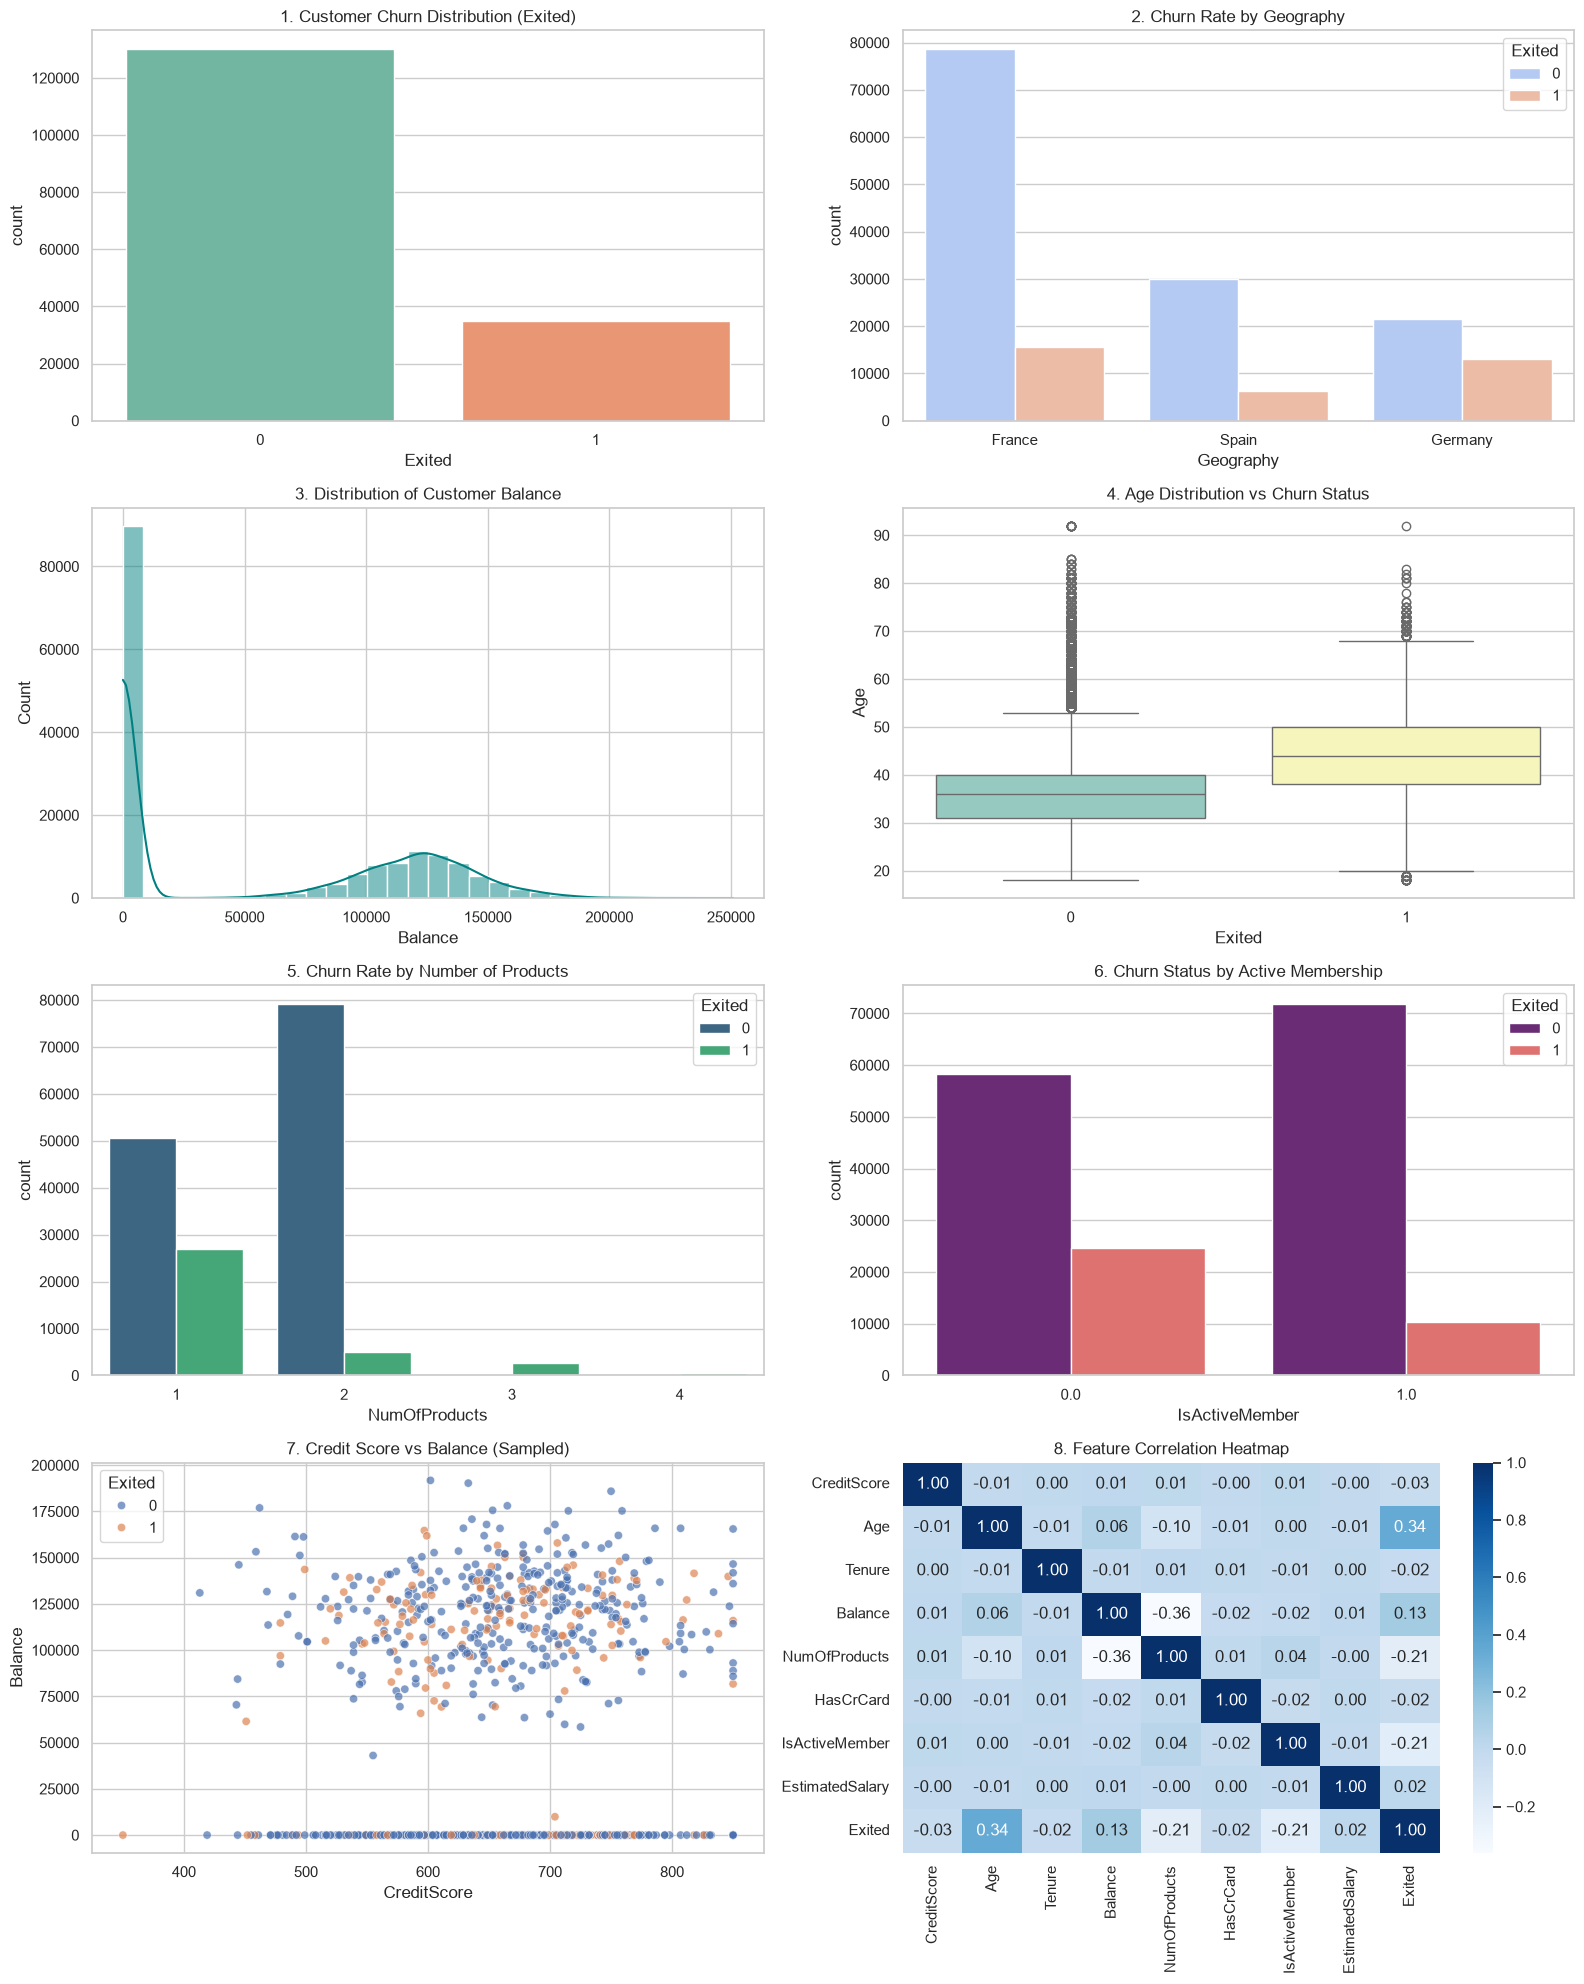

In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(16, 20))


sns.countplot(data=df_clean, x='Exited', hue='Exited', ax=axes[0, 0], palette='Set2', legend=False)
axes[0, 0].set_title('1. Customer Churn Distribution (Exited)')

sns.countplot(data=df_clean, x='Geography', hue='Exited', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('2. Churn Rate by Geography')


sns.histplot(df_clean['Balance'], kde=True, bins=30, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('3. Distribution of Customer Balance')


sns.boxplot(data=df_clean, x='Exited', y='Age', hue='Exited', ax=axes[1, 1], palette='Set3', legend=False)
axes[1, 1].set_title('4. Age Distribution vs Churn Status')


sns.countplot(data=df_clean, x='NumOfProducts', hue='Exited', ax=axes[2, 0], palette='viridis')
axes[2, 0].set_title('5. Churn Rate by Number of Products')


sns.countplot(data=df_clean, x='IsActiveMember', hue='Exited', ax=axes[2, 1], palette='magma')
axes[2, 1].set_title('6. Churn Status by Active Membership')

sns.scatterplot(data=df_clean.sample(1000, random_state=42), x='CreditScore', y='Balance', hue='Exited', ax=axes[3, 0], alpha=0.7)
axes[3, 0].set_title('7. Credit Score vs Balance (Sampled)')

numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='Blues', ax=axes[3, 1])
axes[3, 1].set_title('8. Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [8]:
categorical_cols = ['Geography', 'Gender']
numerical_cols = [col for col in X.columns if col not in categorical_cols]


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [9]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [10]:
X_train_prep = preprocessor.fit_transform(X_train_reg)
X_test_prep = preprocessor.transform(X_test_reg)

In [11]:
print("Data Preprocessing Completed Successfully!")
print(f"X_train shape: {X_train_prep.shape}, X_test shape: {X_test_prep.shape}")

Data Preprocessing Completed Successfully!
X_train shape: (132027, 10), X_test shape: (33007, 10)


In [12]:
results_reg = []

def evaluate_regression_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2}

# A. Baseline Linear Regression
lr = LinearRegression()
lr.fit(X_train_prep, y_train_reg)
y_pred_lr = lr.predict(X_test_prep)
results_reg.append(evaluate_regression_model("Linear Regression (Baseline)", y_test_reg, y_pred_lr))

In [13]:
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])
poly_pipeline.fit(X_train_prep, y_train_reg)
y_pred_poly = poly_pipeline.predict(X_test_prep)
results_reg.append(evaluate_regression_model("Polynomial Regression (Degree 2)", y_test_reg, y_pred_poly))

In [14]:
# C. Ridge Regularization
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_prep, y_train_reg)
y_pred_ridge = ridge.predict(X_test_prep)
results_reg.append(evaluate_regression_model("Ridge Regression", y_test_reg, y_pred_ridge))

In [15]:
# D. Lasso Regularization
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_prep, y_train_reg)
y_pred_lasso = lasso.predict(X_test_prep)
results_reg.append(evaluate_regression_model("Lasso Regression", y_test_reg, y_pred_lasso))


In [16]:
reg_summary_df = pd.DataFrame(results_reg)
print("\n--- Regression Model Comparison Table ---")
display(reg_summary_df)


--- Regression Model Comparison Table ---


,Model,RMSE,MAE,R2 Score
0,Linear Regression (Baseline),49012.993007,40543.967031,0.387836
1,Polynomial Regression (Degree 2),47108.339856,36176.726524,0.434489
2,Ridge Regression,49013.001960,40544.154150,0.387836
3,Lasso Regression,49013.026141,40544.461981,0.387835


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [18]:
y_class = df_clean['Exited']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

X_train_c_prep = preprocessor.fit_transform(X_train_c)
X_test_c_prep = preprocessor.transform(X_test_c)

In [19]:
classifiers = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5,class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results_class = []

In [20]:
results_class = []

for name, clf in classifiers.items():
    clf.fit(X_train_c_prep, y_train_c)
    

    y_train_pred = clf.predict(X_train_c_prep)
    y_test_pred = clf.predict(X_test_c_prep)
    
    results_class.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train_c, y_train_pred),
        'Test Accuracy': accuracy_score(y_test_c, y_test_pred),
        'Train F1': f1_score(y_train_c, y_train_pred),
        'Test F1': f1_score(y_test_c, y_test_pred),
        'Test Precision': precision_score(y_test_c, y_test_pred),
        'Test Recall': recall_score(y_test_c, y_test_pred)
    })

class_summary_df = pd.DataFrame(results_class)
print("--- Classification Model Comparison Table (Train vs Test) ---")
display(class_summary_df)

--- Classification Model Comparison Table (Train vs Test) ---


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Test Precision,Test Recall
0,Logistic Regression,0.753005,0.752901,0.558393,0.557172,0.448749,0.734679
1,Decision Tree,0.800927,0.802557,0.620621,0.620862,0.522881,0.764032
2,KNN,0.881865,0.842246,0.687153,0.577799,0.666106,0.510166
3,Naive Bayes,0.822067,0.821402,0.518942,0.519599,0.602988,0.456472
4,Random Forest,0.994077,0.832581,0.986197,0.619264,0.596813,0.643471
5,Gradient Boosting,0.860725,0.860363,0.612084,0.608910,0.747344,0.513746


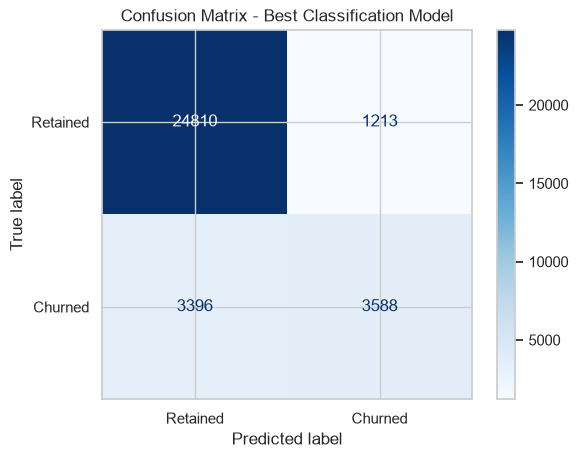

In [21]:
best_model = GradientBoostingClassifier(random_state=42)
best_model.fit(X_train_c_prep, y_train_c)
cm = confusion_matrix(y_test_c, best_model.predict(X_test_c_prep))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Best Classification Model')
plt.show()

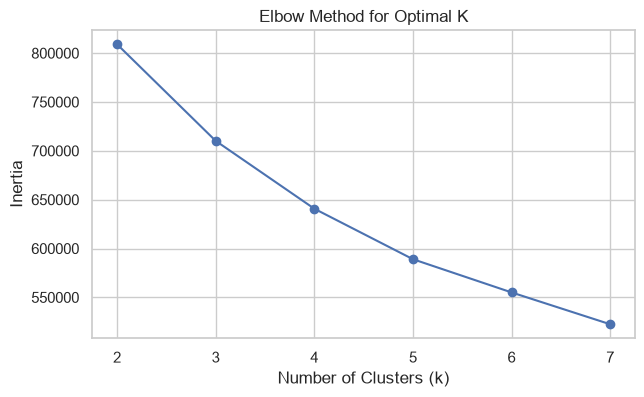

--- Customer Segment Profiles ---


,Age,Balance,NumOfProducts,IsActiveMember,Exited
Cluster,,,,,
0,37.726457,20880.101943,1.824979,1.000000,0.098233
1,39.225737,124223.296919,1.063876,0.478353,0.295274
2,37.392809,19591.592585,1.786182,0.000000,0.241408


In [22]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

cluster_features = df_clean[['Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary']]
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_features)

inertia = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_cluster)

print("--- Customer Segment Profiles ---")
display(df_clean.groupby('Cluster')[['Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited']].mean())

In [23]:
import joblib
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Model saved successfully as binary pkl files!")

Model saved successfully as binary pkl files!
